<a href="https://colab.research.google.com/github/PihuCodeTech/Aircraft-Engine-RUL-Prediction/blob/main/notebooks/TCN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install optuna -q
print("Optuna ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 24.9 MB/s eta 0:00:00
Optuna ready.


In [2]:
import numpy as np, random, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neural_network import MLPRegressor
import tensorflow as tf
import warnings; warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

SEQ_LEN = 40

DATASET_CONFIG = {
    'FD001': {'rul_threshold':125, 'multi_condition':False},
    'FD002': {'rul_threshold':125, 'multi_condition':True},
    'FD003': {'rul_threshold':125, 'multi_condition':False},
    'FD004': {'rul_threshold':125, 'multi_condition':True},
}

# ── Change this path to where your files are ──────────────────────────────────
DATA_PATH = '/content/'   # Colab: files uploaded to content folder
# DATA_PATH = './'        # if files are in same folder as notebook

def load_data(dataset):
    cols     = ['id','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
    train_df = pd.read_csv(f"{DATA_PATH}train_{dataset}.txt",
                           sep=r"\s+", header=None)
    train_df.columns = cols
    test_df  = pd.read_csv(f"{DATA_PATH}test_{dataset}.txt",
                           sep=r"\s+", header=None)
    test_df.columns  = cols
    y_test   = pd.read_csv(f"{DATA_PATH}RUL_{dataset}.txt",
                           header=None).values.flatten()
    return train_df, test_df, y_test

#def mlp_condition_normalize(train_df, test_df, sensor_cols):
    train_df = train_df.copy(); test_df = test_df.copy()
    for col in sensor_cols:
        mlp = MLPRegressor(hidden_layer_sizes=(16,), max_iter=500,
                           random_state=SEED, alpha=0.01)
        mlp.fit(train_df[['op1','op2','op3']], train_df[col])
        train_df[col] = train_df[col] - mlp.predict(train_df[['op1','op2','op3']])
        test_df[col]  = test_df[col]  - mlp.predict(test_df[['op1','op2','op3']])
    return train_df, test_df

def preprocess(train_df, test_df, dataset):
    cfg = DATASET_CONFIG[dataset]
    max_cycle         = train_df.groupby('id')['cycle'].max().reset_index()
    max_cycle.columns = ['id','max_cycle']
    train_df          = train_df.merge(max_cycle, on='id')
    train_df['RUL']   = (train_df['max_cycle'] - train_df['cycle']).clip(upper=cfg['rul_threshold'])
    train_df.drop(columns=['max_cycle'], inplace=True)
    feature_cols = [c for c in train_df.columns if c not in ['id','RUL']]
    sensor_cols  = [c for c in feature_cols if c.startswith('s')]
    #if cfg['multi_condition']:
        #train_df, test_df = mlp_condition_normalize(train_df, test_df, sensor_cols)
    scaler = MinMaxScaler(feature_range=(0,1))
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df[feature_cols]  = scaler.transform(test_df[feature_cols])
    return train_df, test_df, feature_cols

def create_sequences(df, feature_cols, seq_len):
    X_seqs, y_seqs = [], []
    for eid in df['id'].unique():
        data = df[df['id'] == eid][feature_cols + ['RUL']].values
        for i in range(len(data) - seq_len):
            X_seqs.append(data[i:i+seq_len, :-1])
            y_seqs.append(data[i+seq_len, -1])
    return np.array(X_seqs, dtype=np.float32), np.array(y_seqs, dtype=np.float32)

def create_test_sequences(test_df, feature_cols, seq_len):
    X_test = []
    for eid in test_df['id'].unique():
        ed = test_df[test_df['id'] == eid][feature_cols].values
        if len(ed) < seq_len:
            pad = np.zeros((seq_len - len(ed), ed.shape[1]))
            ed  = np.vstack([pad, ed])
        else:
            ed  = ed[-seq_len:]
        X_test.append(ed)
    return np.array(X_test, dtype=np.float32)

def nasa_score(y_true, y_pred):
    diff = y_pred - y_true
    return float(np.sum(np.where(diff < 0, np.exp(-diff/13)-1, np.exp(diff/10)-1)))

def report_metrics(name, true, pred):
    mse  = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(true, pred)
    nasa = nasa_score(true, pred)
    print(f"{name:40s} MSE={mse:.3f} RMSE={rmse:.3f} MAE={mae:.3f} NASA={nasa:.1f}")
    return rmse, mae, mse, nasa

def plot_loss(h, name, ds):
    plt.figure(figsize=(10,5))
    plt.plot(h.history['loss'],     label='Train Loss')
    plt.plot(h.history['val_loss'], label='Val Loss')
    plt.title(f'{name} — Loss vs Epoch ({ds})')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(); plt.show()

def plot_predictions(y_test, pred, name, ds):
    plt.figure(figsize=(14,5))
    plt.plot(y_test, label='Actual RUL', linewidth=2, color='black')
    plt.plot(pred,   label=f'{name} Predicted', linewidth=1.5,
             color='blue', alpha=0.8)
    plt.title(f'Actual vs Predicted RUL — {name} ({ds})')
    plt.xlabel('Engine Index'); plt.ylabel('RUL')
    plt.legend(); plt.grid(); plt.show()

def plot_residuals(y_test, pred, name, ds):
    res = y_test - pred
    plt.figure(figsize=(10,4))
    plt.scatter(range(len(res)), res, alpha=0.6, color='steelblue')
    plt.axhline(0, linestyle='--', color='black')
    plt.title(f'Residuals — {name} ({ds})')
    plt.xlabel('Engine Index'); plt.ylabel('Residual')
    plt.grid(); plt.show()

def plot_rmse_bar(results_dict, model_name):
    datasets  = list(results_dict.keys())
    rmse_vals = [results_dict[ds]['rmse'] for ds in datasets]
    plt.figure(figsize=(8,5))
    bars = plt.bar(datasets, rmse_vals, color='steelblue', edgecolor='white')
    plt.bar_label(bars, fmt='%.3f', padding=3)
    plt.title(f'{model_name} — Test RMSE Across Datasets')
    plt.ylabel('RMSE'); plt.grid(axis='y'); plt.show()

def plot_rul_dist(train_df, ds):
    plt.figure(figsize=(10,5))
    plt.hist(train_df['RUL'], bins=40, color='steelblue', edgecolor='white')
    plt.title(f'RUL Distribution — {ds}')
    plt.xlabel('RUL'); plt.ylabel('Frequency')
    plt.grid(); plt.show()

# Quick check that files load correctly
print("Testing data loading...")
for ds in ['FD001','FD002','FD003','FD004']:
    tr, te, y = load_data(ds)
    print(f"  {ds}: train={tr.shape} test={te.shape} y_test={y.shape}")
print("All datasets loaded successfully.")

Testing data loading...
  FD001: train=(20631, 26) test=(13096, 26) y_test=(100,)
  FD002: train=(53759, 26) test=(33991, 26) y_test=(259,)
  FD003: train=(24720, 26) test=(16596, 26) y_test=(100,)
  FD004: train=(61249, 26) test=(41214, 26) y_test=(248,)
All datasets loaded successfully.


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL B — TCN WORKER + SEARCH FUNCTIONS
# No shell commands inside this cell.
# ══════════════════════════════════════════════════════════════════════════════
import gc, optuna, subprocess, json, sys, os, ctypes
import numpy as np
optuna.logging.set_verbosity(optuna.logging.WARNING)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, GlobalAveragePooling1D,
    LayerNormalization, MultiHeadAttention, Add, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: [tf.config.experimental.set_memory_growth(g, True) for g in gpus]
    except RuntimeError: pass

WORKER_PATH  = '/tmp/tcn_worker.py'
ARRAY_PREFIX = '/tmp/tcn_arrays'
DILATION_OPTIONS = [[1,2,4,8],[1,2,4,8,16],[2,4,6,8],[2,4,8,16],[1,2,4],[2,4,8]]

def _trim_ram():
    try: ctypes.cdll.LoadLibrary("libc.so.6").malloc_trim(0)
    except Exception: pass

# ── Worker script — runs inside each subprocess, dies after one trial ──────────
WORKER_CODE = r"""
import os, sys, json, numpy as np
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONWARNINGS']       = 'ignore'
import warnings; warnings.filterwarnings('ignore')

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: [tf.config.experimental.set_memory_growth(g, True) for g in gpus]
    except: pass

from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, GlobalAveragePooling1D,
    LayerNormalization, MultiHeadAttention, Add, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber

DILATION_OPTIONS = [[1,2,4,8],[1,2,4,8,16],[2,4,6,8],[2,4,8,16],[1,2,4],[2,4,8]]

def _blk(x, f, k, d, dr):
    r = x
    x = Conv1D(f, k, padding='causal', dilation_rate=d, activation='relu')(x)
    x = BatchNormalization()(x); x = Dropout(dr)(x)
    x = Conv1D(f, k, padding='causal', dilation_rate=d, activation='relu')(x)
    x = BatchNormalization()(x)
    if r.shape[-1] != f: r = Conv1D(f, 1, padding='same')(r)
    return Add()([x, r])

def build_tcn(sl, nf, hp):
    inp = Input(shape=(sl, nf)); x = inp
    for d in hp['dilations']:
        x = _blk(x, hp['filters'], hp['kernel_size'], d, hp['dropout'])
    at = MultiHeadAttention(num_heads=hp['attn_heads'],
                             key_dim=hp['attn_key_dim'], dropout=0.05)(x, x)
    x  = LayerNormalization()(Add()([x, at]))
    x  = GlobalAveragePooling1D()(x)
    x  = Dense(hp['dense_units'], activation='relu')(x)
    x  = Dropout(hp['dropout'])(x)
    m  = Model(inp, Dense(1)(x))
    m.compile(optimizer=Adam(hp['lr'], clipnorm=1.0), loss=Huber(), metrics=['mae'])
    return m

hp     = json.loads(sys.argv[1])
prefix = sys.argv[2]
SEQ    = int(sys.argv[3]) if len(sys.argv) > 3 else 40

hp['dilations'] = DILATION_OPTIONS[hp['dil_idx']]   # reconstruct from index

Xtr  = np.load(f'{prefix}_Xtr.npy')
ytr  = np.load(f'{prefix}_ytr.npy')
Xval = np.load(f'{prefix}_Xval.npy')
yval = np.load(f'{prefix}_yval.npy')

cbs = [EarlyStopping(monitor='val_loss', patience=hp['patience_es'],
                     restore_best_weights=True),
       ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                         patience=hp.get('patience_lr', 5), min_lr=1e-7)]
try:
    m = build_tcn(SEQ, Xtr.shape[2], hp)
    m.fit(Xtr, ytr, validation_data=(Xval, yval),
          epochs=hp['epochs'], batch_size=hp['batch_size'],
          callbacks=cbs, verbose=0)
    for cb in cbs:
        if hasattr(cb, 'best_weights'): cb.best_weights = None
    vp = m.predict(Xval, verbose=0).flatten()
    print(float(np.sqrt(mean_squared_error(yval, vp))))
    sys.exit(0)
except Exception:
    import traceback; traceback.print_exc(file=sys.stderr)
    sys.exit(1)
"""

# ── Write worker to disk ───────────────────────────────────────────────────────
def write_worker():
    with open(WORKER_PATH, 'w') as f:
        f.write(WORKER_CODE)
    print(f"  Worker written → {WORKER_PATH}")

# ── Run one trial in a fresh subprocess ───────────────────────────────────────
def run_isolated(hp, timeout=360):
    """
    Spawns a new Python process per trial.
    OS reclaims 100% of TF memory when process exits.
    Parent process accumulates nothing — no more OOM crashes.
    """
    try:
        r = subprocess.run(
            [sys.executable, WORKER_PATH,
             json.dumps(hp), ARRAY_PREFIX, str(SEQ_LEN)],
            capture_output=True, text=True, timeout=timeout)
        if r.returncode == 0 and r.stdout.strip():
            return float(r.stdout.strip())
        if r.stderr:
            print(f"    [err] {r.stderr.strip()[-200:]}")
        return float('inf')
    except subprocess.TimeoutExpired:
        print(f"    [timeout {timeout}s]")
        return float('inf')
    except Exception as e:
        print(f"    [exc] {e}")
        return float('inf')

# ── Save precomputed arrays to disk, free from parent RAM ─────────────────────
def save_arrays(Xtr, ytr, Xval, yval):
    np.save(f'{ARRAY_PREFIX}_Xtr.npy',  Xtr)
    np.save(f'{ARRAY_PREFIX}_ytr.npy',  ytr)
    np.save(f'{ARRAY_PREFIX}_Xval.npy', Xval)
    np.save(f'{ARRAY_PREFIX}_yval.npy', yval)
    mb = (Xtr.nbytes + Xval.nbytes) / 1e6
    print(f"  Arrays saved to {ARRAY_PREFIX}_*.npy  ({mb:.0f} MB on disk)")

# ── Build TCN (used in Cell D retrain — runs in-process, not subprocess) ──────
def build_tcn_s(seq_len, n_features, hp):
    inp = Input(shape=(seq_len, n_features)); x = inp
    for d in hp['dilations']:
        x = _blk_main(x, hp['filters'], hp['kernel_size'], d, hp['dropout'])
    at = MultiHeadAttention(num_heads=hp['attn_heads'],
                             key_dim=hp['attn_key_dim'], dropout=0.05)(x, x)
    x  = LayerNormalization()(Add()([x, at]))
    x  = GlobalAveragePooling1D()(x)
    x  = Dense(hp['dense_units'], activation='relu')(x)
    x  = Dropout(hp['dropout'])(x)
    m  = Model(inp, Dense(1)(x))
    m.compile(optimizer=Adam(hp['lr'], clipnorm=1.0), loss=Huber(), metrics=['mae'])
    return m

def _blk_main(x, f, k, d, dr):
    r = x
    x = Conv1D(f, k, padding='causal', dilation_rate=d, activation='relu')(x)
    x = BatchNormalization()(x); x = Dropout(dr)(x)
    x = Conv1D(f, k, padding='causal', dilation_rate=d, activation='relu')(x)
    x = BatchNormalization()(x)
    if r.shape[-1] != f: r = Conv1D(f, 1, padding='same')(r)
    return Add()([x, r])

# ── Callbacks (used in Cell D retrain) ────────────────────────────────────────
def get_cbs(hp):
    return [
        EarlyStopping(monitor='val_loss', patience=hp['patience_es'],
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=hp['lr_factor'],
                          patience=hp['patience_lr'],
                          min_lr=hp['min_lr'], verbose=1)
    ]

# ── Shared Phase 2: warm-start Bayesian from Phase 1 top_n ────────────────────
def _run_phase2(rs, n_bayes, top_n, objective_fn):
    sorted_t    = sorted(rs.trials, key=lambda t: t.value)
    seeds       = [(t.params, t.distributions, t.value) for t in sorted_t[:top_n]]
    p1_best     = sorted_t[0].value
    del sorted_t; gc.collect()

    bs = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=top_n))

    # add_trial: transfers results with ZERO re-evaluation, ZERO GPU cost
    for p, d, v in seeds:
        bs.add_trial(optuna.trial.create_trial(params=p, distributions=d, value=v))
    del seeds; gc.collect()

    print(f"  {top_n} seeds transferred (0 GPU). "
          f"Running {n_bayes} new Bayesian trials...")

    def _cb(study, trial):
        v   = trial.value
        tag = '← BEST' if v == study.best_value else ''
        print(f"    Trial {trial.number+1:3d}: "
              f"{'inf' if v==float('inf') else f'{v:.3f}'} {tag}")

    bs.optimize(objective_fn, n_trials=n_bayes, callbacks=[_cb])

    best = bs.best_trial
    print(f"\n  Phase1 best={p1_best:.3f}  "
          f"Phase2 best={best.value:.3f}  "
          f"Δ={p1_best-best.value:+.3f}")

    try:
        imp = optuna.importance.get_param_importances(bs)
        plt.figure(figsize=(10, 4))
        plt.barh(list(imp.keys()), list(imp.values()), color='steelblue')
        plt.title('HP Importance — TCN (Subprocess Bayesian)')
        plt.tight_layout(); plt.grid(axis='x'); plt.show()
    except Exception:
        pass
    return bs

# ── TCN combined search ────────────────────────────────────────────────────────
def tcn_combined_search(n_random=20, n_bayes=20, top_n=5,
                         dataset='FD001', epochs_search=40):
    print(f"\n{'═'*65}")
    print(f"  TCN COMBINED SEARCH  |  {dataset}")
    print(f"  Phase1: Random {n_random}  |  Phase2: Bayesian {n_bayes} new trials")
    print(f"  Each trial = fresh subprocess → TF RAM fully reclaimed after exit")
    print(f"  Total subprocess evaluations: {n_random + n_bayes}")
    print(f"{'═'*65}")

    # ── Write worker to disk ─────────────────────────────────────────────────
    write_worker()

    # ── Precompute sequences, save to disk, FREE from parent RAM ─────────────
    # Parent process holds zero TF state and zero training arrays during search
    tr, _, _            = load_data(dataset)
    train_df, _, feat   = preprocess(tr.copy(), tr.copy(), dataset)
    del tr
    eids        = train_df['id'].unique()
    tr_e, val_e = train_test_split(eids, test_size=0.2, random_state=SEED)
    Xtr,  ytr   = create_sequences(train_df[train_df['id'].isin(tr_e)], feat, SEQ_LEN)
    Xval, yval  = create_sequences(train_df[train_df['id'].isin(val_e)], feat, SEQ_LEN)
    del train_df
    save_arrays(Xtr, ytr, Xval, yval)
    del Xtr, ytr, Xval, yval     # free from parent — subprocess reads from disk
    gc.collect(); _trim_ram()

    # ── Objective: one subprocess per trial ──────────────────────────────────
    def objective(trial):
        hp = {
            'filters'     : trial.suggest_categorical('filters',      [32,64,128]),
            'kernel_size' : trial.suggest_categorical('kernel_size',  [2,3,4]),
            'dil_idx'     : trial.suggest_categorical(
                                'dil_idx', list(range(len(DILATION_OPTIONS)))),
            'attn_heads'  : trial.suggest_categorical('attn_heads',   [2,4,8]),
            'attn_key_dim': trial.suggest_categorical('attn_key_dim', [8,16,32,64]),
            'dense_units' : trial.suggest_categorical('dense_units',  [32,64,128]),
            'dropout'     : trial.suggest_float('dropout',             0.05, 0.40),
            'lr'          : trial.suggest_float('lr',                  1e-4, 1e-2, log=True),
            'batch_size'  : trial.suggest_categorical('batch_size',   [32,64,128]),
            'epochs'      : epochs_search,
            'patience_es' : 10,
            'patience_lr' : 4,
        }
        return run_isolated(hp)   # subprocess call — parent RAM stays flat

    # ── Phase 1: Random ──────────────────────────────────────────────────────
    print(f"\n  ── Phase 1: Random Search ({n_random} trials) ──")
    rs = optuna.create_study(direction='minimize',
                              sampler=optuna.samplers.RandomSampler(seed=SEED))

    def _cb1(study, trial):
        v   = trial.value
        tag = '← BEST' if v == study.best_value else ''
        print(f"    Trial {trial.number+1:3d}: "
              f"{'inf' if v==float('inf') else f'{v:.3f}'} {tag}")

    rs.optimize(objective, n_trials=n_random, callbacks=[_cb1])

    print(f"\n  Top {top_n} from Phase 1:")
    sorted_show = sorted(rs.trials, key=lambda t: t.value)
    for i, t in enumerate(sorted_show[:top_n]):
        p = t.params
        print(f"    #{i+1}  RMSE={t.value:.3f}  "
              f"filt={p['filters']}  dil={p['dil_idx']}  lr={p['lr']:.1e}")
    del sorted_show

    # ── Phase 2: Bayesian warm-started ───────────────────────────────────────
    print(f"\n  ── Phase 2: Bayesian ({n_bayes} new trials) ──")
    bs = _run_phase2(rs, n_bayes, top_n, objective)

    # ── Build best HP for full training ──────────────────────────────────────
    p = bs.best_trial.params
    best_hp = {
        'filters'     : p['filters'],
        'kernel_size' : p['kernel_size'],
        'dilations'   : DILATION_OPTIONS[p['dil_idx']],
        'attn_heads'  : p['attn_heads'],
        'attn_key_dim': p['attn_key_dim'],
        'dense_units' : p['dense_units'],
        'dropout'     : p['dropout'],
        'lr'          : p['lr'],
        'batch_size'  : p['batch_size'],
        'epochs'      : 100,
        'patience_es' : 25,
        'patience_lr' : 6,
        'lr_factor'   : 0.5,
        'min_lr'      : 1e-7,
    }
    print(f"\n  Best HP: {best_hp}")
    return best_hp, rs, bs

print("TCN functions loaded. Run Cell C to start search.")

TCN functions loaded. Run Cell C to start search.



═════════════════════════════════════════════════════════════════
  TCN COMBINED SEARCH  |  FD001
  Phase1: Random 20  |  Phase2: Bayesian 20 new trials
  Each trial = fresh subprocess → TF RAM fully reclaimed after exit
  Total subprocess evaluations: 40
═════════════════════════════════════════════════════════════════
  Worker written → /tmp/tcn_worker.py
  Arrays saved to /tmp/tcn_arrays_*.npy  (67 MB on disk)

  ── Phase 1: Random Search (20 trials) ──
    Trial   1: 12.736 ← BEST
    Trial   2: 12.295 ← BEST
    Trial   3: 12.705 
    Trial   4: 13.092 
    Trial   5: 13.780 
    Trial   6: 12.396 
    Trial   7: 12.069 ← BEST
    Trial   8: 10.928 ← BEST
    Trial   9: 13.993 
    Trial  10: 11.800 
    Trial  11: 11.873 
    Trial  12: 12.245 
    Trial  13: 13.000 
    Trial  14: 11.195 
    Trial  15: 11.968 
    Trial  16: 11.171 
    Trial  17: 12.874 
    Trial  18: 12.032 
    Trial  19: 11.779 
    Trial  20: 11.269 

  Top 5 from Phase 1:
    #1  RMSE=10.928  filt=128  

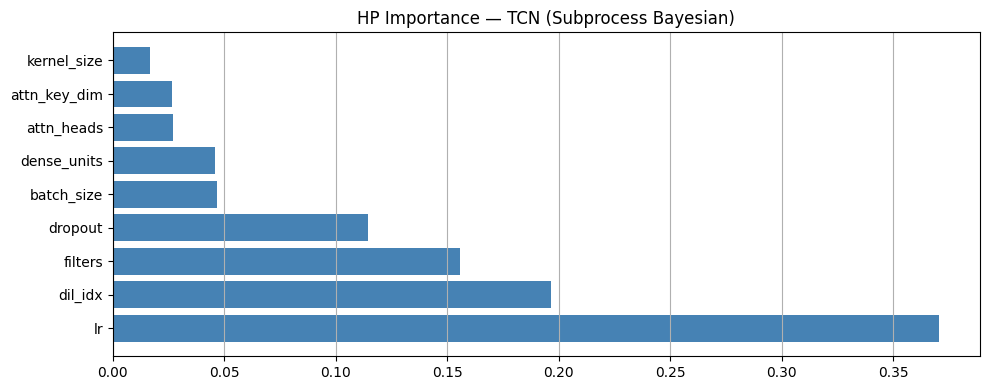


  Best HP: {'filters': 32, 'kernel_size': 2, 'dilations': [1, 2, 4, 8, 16], 'attn_heads': 8, 'attn_key_dim': 16, 'dense_units': 64, 'dropout': 0.23539663251330034, 'lr': 0.005117547312935309, 'batch_size': 128, 'epochs': 100, 'patience_es': 25, 'patience_lr': 6, 'lr_factor': 0.5, 'min_lr': 1e-07}


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL C — RUN SEARCH
# ══════════════════════════════════════════════════════════════════════════════
best_hp_tcn, rs_tcn, bo_tcn = tcn_combined_search(
    n_random=20, n_bayes=20, top_n=5,
    dataset='FD001', epochs_search=40)


██████████████████████████████████████████████████
  TCN | FD001
██████████████████████████████████████████████████

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0025587736163288355.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0012793868081644177.

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0006396934040822089.

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.00031984670204110444.

Epoch 47: ReduceLROnPlateau reducing learning rate to 0.00015992335102055222.

Epoch 53: ReduceLROnPlateau reducing learning rate to 7.996167551027611e-05.

  Val:
TCN                                      MSE=148.986 RMSE=12.206 MAE=7.772 NASA=10507.4
  Test:
TCN                                      MSE=459.177 RMSE=21.428 MAE=12.543 NASA=12262.7


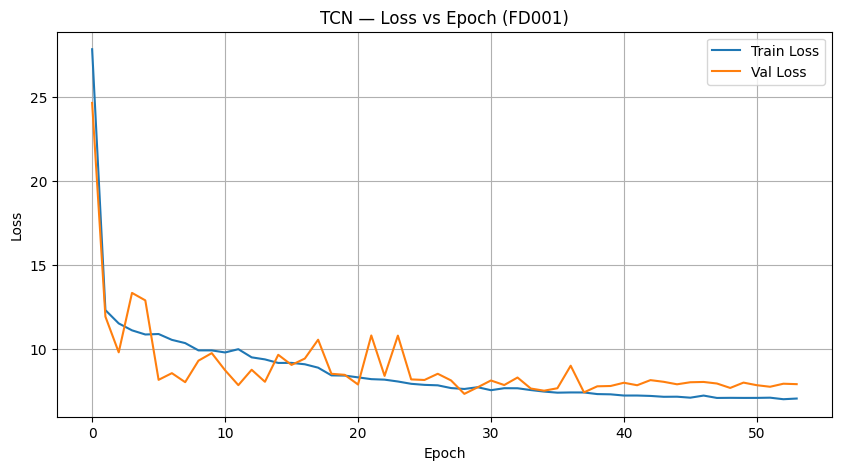

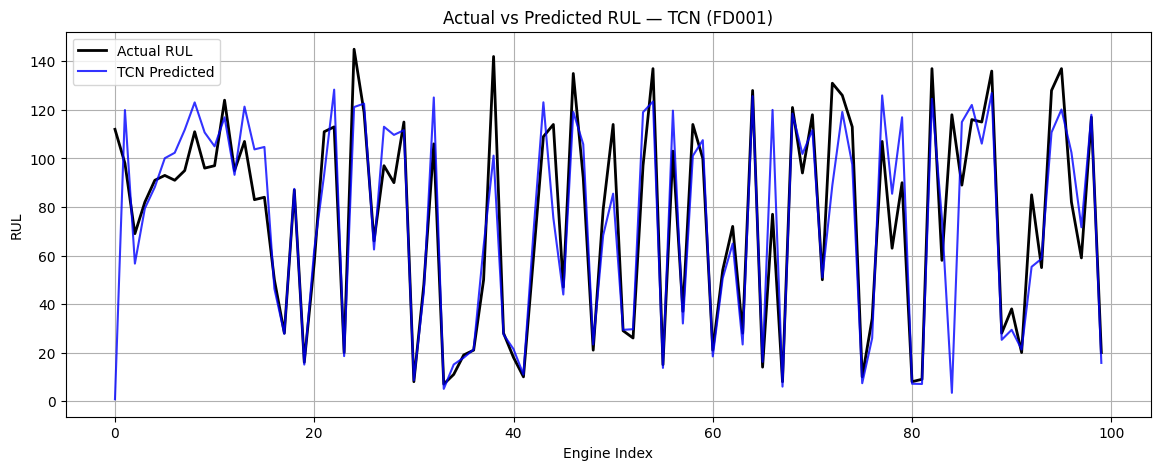


██████████████████████████████████████████████████
  TCN | FD002
██████████████████████████████████████████████████

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0025587736163288355.

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0012793868081644177.

Epoch 36: ReduceLROnPlateau reducing learning rate to 0.0006396934040822089.

Epoch 42: ReduceLROnPlateau reducing learning rate to 0.00031984670204110444.

Epoch 48: ReduceLROnPlateau reducing learning rate to 0.00015992335102055222.

Epoch 54: ReduceLROnPlateau reducing learning rate to 7.996167551027611e-05.

  Val:
TCN                                      MSE=268.654 RMSE=16.391 MAE=11.928 NASA=62305.6
  Test:
TCN                                      MSE=1317.416 RMSE=36.296 MAE=22.343 NASA=611818.6


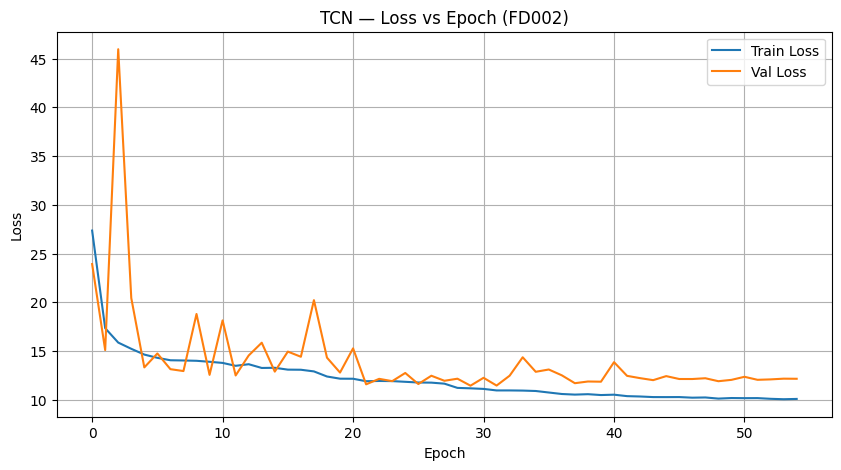

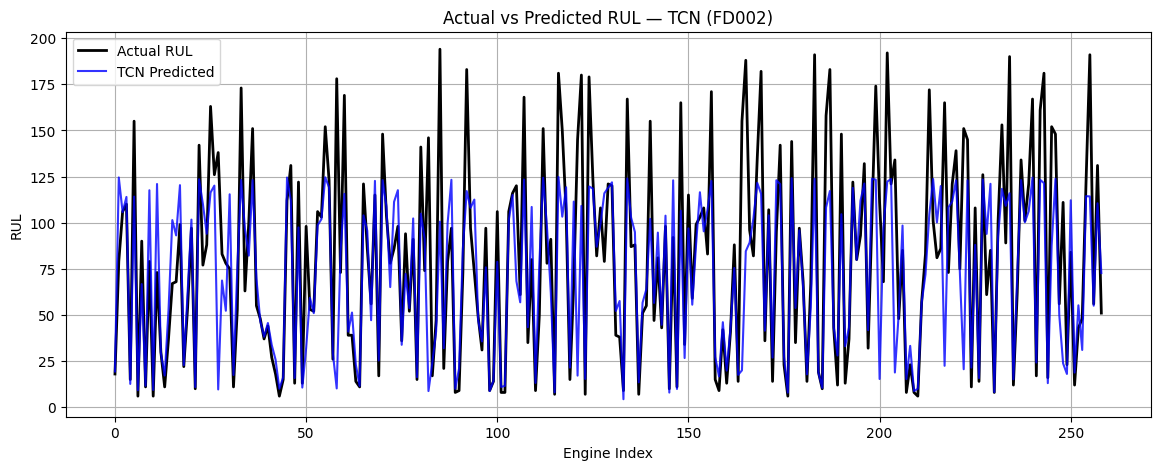


██████████████████████████████████████████████████
  TCN | FD003
██████████████████████████████████████████████████

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0025587736163288355.

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0012793868081644177.

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0006396934040822089.

Epoch 46: ReduceLROnPlateau reducing learning rate to 0.00031984670204110444.

Epoch 52: ReduceLROnPlateau reducing learning rate to 0.00015992335102055222.

Epoch 58: ReduceLROnPlateau reducing learning rate to 7.996167551027611e-05.

  Val:
TCN                                      MSE=112.744 RMSE=10.618 MAE=6.319 NASA=7439.0
  Test:
TCN                                      MSE=203.925 RMSE=14.280 MAE=9.665 NASA=501.7


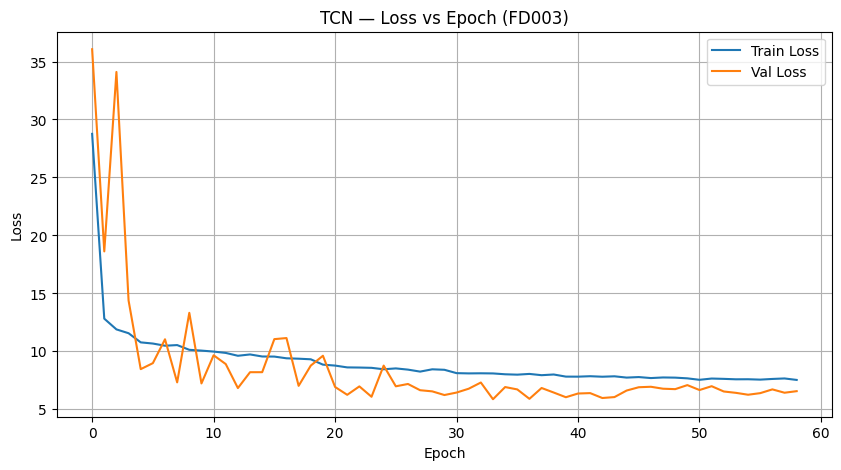

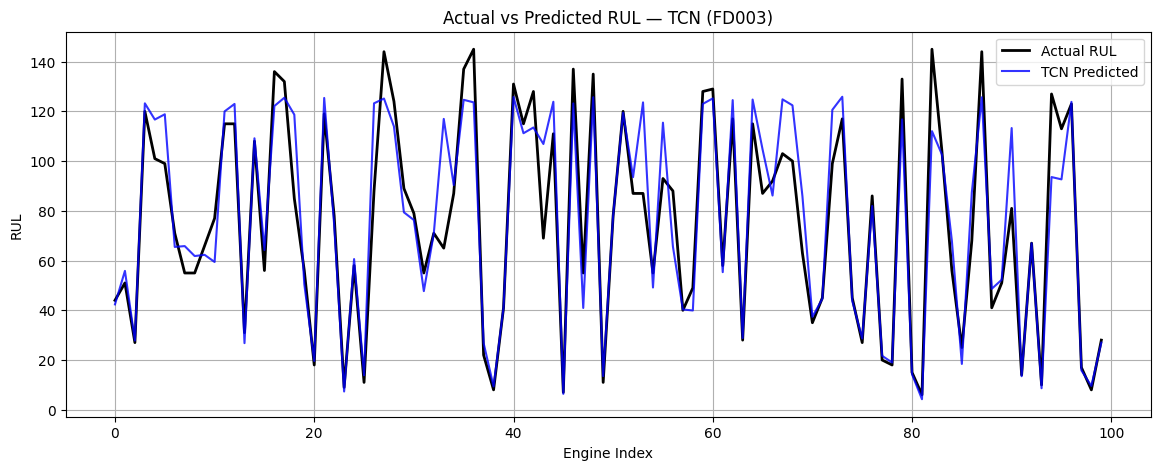


██████████████████████████████████████████████████
  TCN | FD004
██████████████████████████████████████████████████

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0025587736163288355.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0012793868081644177.

Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0006396934040822089.

Epoch 37: ReduceLROnPlateau reducing learning rate to 0.00031984670204110444.

Epoch 43: ReduceLROnPlateau reducing learning rate to 0.00015992335102055222.

  Val:
TCN                                      MSE=446.306 RMSE=21.126 MAE=14.824 NASA=308988.8
  Test:
TCN                                      MSE=867.718 RMSE=29.457 MAE=22.685 NASA=10287.2


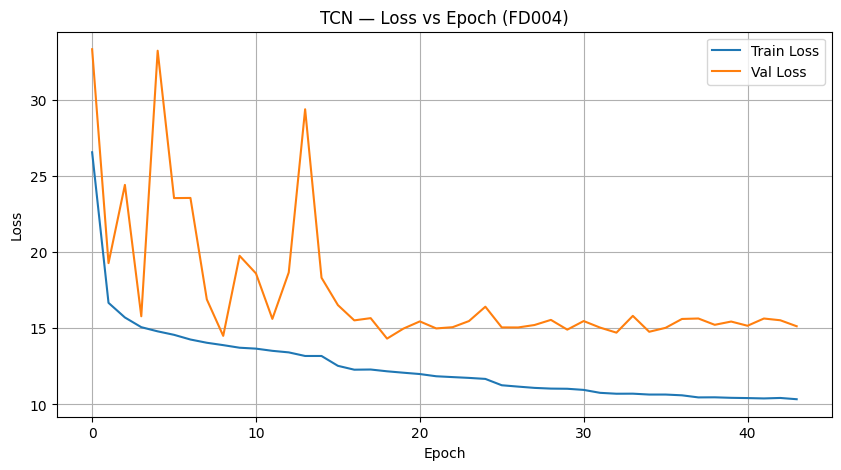

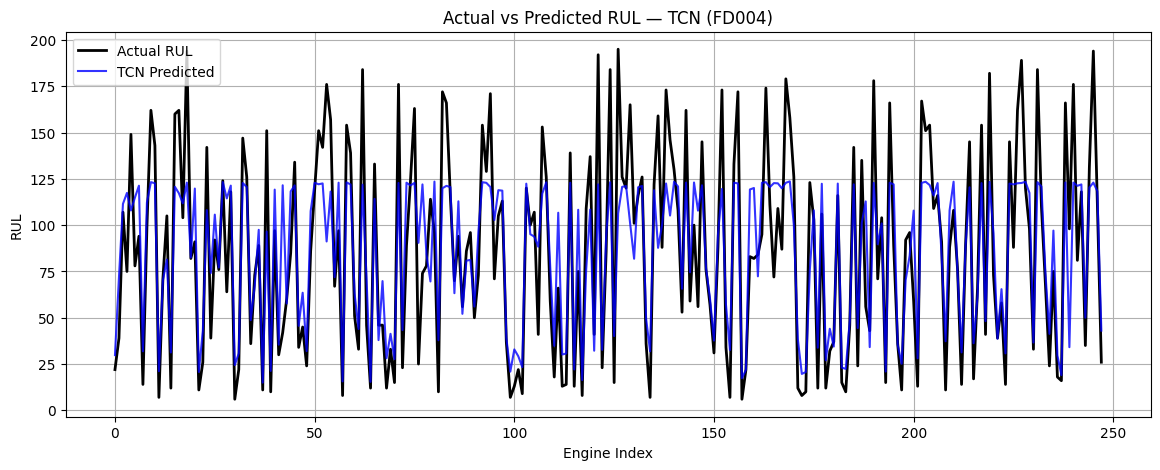


══════════════════════════════════════════════════
  DS             RMSE
  ──────── ──────────
  FD001        21.428
  FD002        36.296
  FD003        14.280
  FD004        29.457


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL D — RETRAIN BEST HP ON ALL 4 DATASETS
# Runs in-process (not subprocess) — only 4 training runs, no accumulation
# ══════════════════════════════════════════════════════════════════════════════
DATASETS      = ['FD001','FD002','FD003','FD004']
optimized_tcn = {}

for dataset in DATASETS:
    print(f"\n{'█'*50}\n  TCN | {dataset}\n{'█'*50}")
    np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

    X_train = y_train = X_val = y_val = X_test = model = cbs = None
    try:
        tr, te, y_test          = load_data(dataset)
        train_df, test_df, feat = preprocess(tr.copy(), te.copy(), dataset)
        del tr, te

        eids        = train_df['id'].unique()
        tr_e, val_e = train_test_split(eids, test_size=0.2, random_state=SEED)
        X_train, y_train = create_sequences(
            train_df[train_df['id'].isin(tr_e)], feat, SEQ_LEN)
        X_val,   y_val   = create_sequences(
            train_df[train_df['id'].isin(val_e)], feat, SEQ_LEN)
        X_test           = create_test_sequences(test_df, feat, SEQ_LEN)
        del train_df, test_df

        model = build_tcn_s(SEQ_LEN, X_train.shape[2], best_hp_tcn)
        cbs   = get_cbs(best_hp_tcn)
        hist  = model.fit(X_train, y_train,
                          validation_data=(X_val, y_val),
                          epochs=best_hp_tcn['epochs'],
                          batch_size=best_hp_tcn['batch_size'],
                          callbacks=cbs, verbose=0)

        vp = model.predict(X_val,  verbose=0).flatten()
        tp = model.predict(X_test, verbose=0).flatten()

        print("\n  Val:")
        report_metrics("TCN", y_val, vp)
        print("  Test:")
        r, m, ms, n = report_metrics("TCN", y_test, tp)
        optimized_tcn[dataset] = {
            'rmse':r, 'mae':m, 'mse':ms, 'nasa':n, 'test_preds':tp}

        plot_loss(hist, 'TCN', dataset)
        plot_predictions(y_test, tp, 'TCN', dataset)
        del vp, hist

    finally:
        if cbs is not None:
            for cb in cbs:
                if hasattr(cb, 'best_weights'):
                    cb.best_weights = None
        model = cbs = X_train = y_train = X_val = y_val = X_test = None
        tf.keras.backend.clear_session()
        gc.collect(); gc.collect()
        _trim_ram()

print(f"\n{'═'*50}")
print(f"  {'DS':<8} {'RMSE':>10}")
print(f"  {'':─<8} {'':─>10}")
for ds in DATASETS:
    o = optimized_tcn[ds]['rmse']
    if 'all_results' in globals() and ds in all_results:
        b = all_results[ds]['rmse']
        print(f"  {ds:<8} {o:>10.3f}  ({o-b:+.3f} vs baseline)")
    else:
        print(f"  {ds:<8} {o:>10.3f}")